## Bibliotecas

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Funções

In [ ]:
pd.options.display.max_columns = 200
pd.options.display.width = 200

def load_processed_data(path='data/dados_tratados.csv', save_back=True):
    if os.path.exists(path):
        df = pd.read_csv(path, sep=';', encoding='utf-8-sig')
    else:
        raise FileNotFoundError(f'Arquivo de dados tratados não encontrado: {path}. Execute o notebook principal para gerar `data/dados_tratados.csv`')

    # Coerce colunas numéricas comuns
    for c in ['IEG','IDA','IPV','IAA','IPS','IPP','INDE','IAN','ano_ref','Idade','Mat','Por','Ing']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # Criar categoria IAN amigável
    if 'IAN' in df.columns and 'IAN_cat' not in df.columns:
        df['IAN_cat'] = df['IAN'].astype(float).map({0.0: '0 - Severo', 5.0: '5 - Moderado', 10.0: '10 - Adequado'}).fillna('Outros/Não Informado')

    # Unificar coluna 'Pedra' a partir de possíveis colunas existentes (prioridade mais recente)
    candidates = ['Pedra 2024','Pedra 23','Pedra 2023','Pedra 22','Pedra 21','Pedra 20']
    pedra_cols = [c for c in candidates if c in df.columns]
    if not pedra_cols:
        pedra_cols = [c for c in df.columns if 'Pedra' in c]
    if pedra_cols:
        df['Pedra'] = pd.NA
        for col in pedra_cols:
            # substituir strings vazias por NA e preencher Pedra com o primeiro valor disponível
            vals = df[col].replace('', pd.NA) if col in df.columns else pd.Series([pd.NA]*len(df))
            # atribuir apenas onde 'Pedra' é NA para evitar downcasting silencioso com .fillna
            mask = df['Pedra'].isna()
            df.loc[mask, 'Pedra'] = vals[mask].values
        df['Pedra'] = df['Pedra'].astype(object).where(pd.notna(df['Pedra']), pd.NA)
    else:
        df['Pedra'] = pd.NA

    # Se solicitado, salvar de volta o CSV com a nova coluna (sobrescreve)
    if save_back:
        df.to_csv(path, sep=';', index=False, encoding='utf-8-sig')

    return df


def _plot_metric(metric, item_num, tmp, fase_order):
    if metric not in tmp.columns:
        print(f"[AVISO] Coluna {metric} não existe.")
        return

    aux = tmp[['ano_ref', 'Fase_num', 'Fase_lbl', metric]].copy()
    aux[metric] = pd.to_numeric(aux[metric], errors='coerce')
    aux = aux.dropna(subset=['ano_ref', 'Fase_num', metric])

    grp = (aux.groupby(['ano_ref', 'Fase_num', 'Fase_lbl'])[metric]
              .mean()
              .reset_index()
              .sort_values(['ano_ref', 'Fase_num']))

    plt.figure(figsize=(12, 4))
    for yr, g in grp.groupby('ano_ref'):
        plt.plot(g['Fase_lbl'], g[metric], marker='o', label=str(int(yr)))

    plt.title(f'Item {item_num} — Média de {metric} por Fase (2022/2023/2024)')
    plt.xlabel('Fase')
    plt.ylabel(metric)
    plt.legend(title='Ano', ncol=3, fontsize=9)
    plt.xticks(fase_order, rotation=0)
    plt.tight_layout()
    plt.show()

base = load_processed_data()

base.head()

,RA,Nome_Anon,Idade,Gênero,INDE,IAA,IEG,IPS,IDA,IPV,IAN,Defasagem,Fase Ideal,IPP,ano_ref,Fase,risco,IAN_cat,Pedra
0,RA-1,Aluno-1,19.0,Menina,5.783,8.3,4.1,5.6,4.0,7.278,5.0,-1,NaN,NaN,2022,7,1,5 - Moderado,<NA>
1,RA-1,Aluno-1,NaN,Menina,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0,Fase 8 (Universitários),NaN,2023,FASE 8,0,10 - Adequado,<NA>
2,RA-1,Aluno-1,21.0,Menina,NaN,NaN,0.0,NaN,NaN,NaN,10.0,0,Fase 8 (Universitários),NaN,2024,8E,0,10 - Adequado,<NA>
3,RA-10,Aluno-10,18.0,Menina,5.784,8.3,5.2,5.0,4.1,7.056,5.0,-1,NaN,NaN,2022,7,1,5 - Moderado,<NA>
4,RA-100,Aluno-100,13.0,Menina,7.618,8.8,7.8,5.0,7.6,7.250,10.0,1,NaN,NaN,2022,4,0,10 - Adequado,<NA>


## Análises

In [40]:
metric = 'IAN'
item_num = 1

tmp = base.copy()

# Garantir colunas numéricas
for c in ['IEG', 'IDA', 'IPV', 'IAA', 'IPS', 'IPP', 'INDE']:
    if c in tmp.columns:
        tmp[c] = pd.to_numeric(tmp[c], errors='coerce')

# Criar categoria IAN se não existir
if 'IAN_cat' not in tmp.columns and 'IAN' in tmp.columns:
    tmp['IAN_cat'] = tmp['IAN'].astype(float).map(
        {0.0: '0 - Severo', 5.0: '5 - Moderado', 10.0: '10 - Adequado'}).fillna('Outros/Não Informado')

# Normalizar ano
tmp['ano_ref'] = pd.to_numeric(tmp.get('ano_ref'), errors='coerce')

# Criar label curto de fase: "F1", "F2"...
if 'Fase' in tmp.columns:
    fase_raw = tmp['Fase'].astype(str).str.strip()

    # Extrai o primeiro número que aparecer (ex: "Fase 3", "3", "Fase 03 - ..." -> 3)
    fase_num = pd.to_numeric(fase_raw.str.extract(r'(\d+)')[0], errors='coerce')

    # Se não achar número, tenta mapear por ordem de aparição
    if fase_num.isna().all():
        uniq = pd.Series(fase_raw.unique())
        mapping = {v: i+1 for i, v in enumerate(uniq)}
        fase_num = fase_raw.map(mapping)

    tmp['Fase_num'] = fase_num
    tmp['Fase_lbl'] = 'F' + tmp['Fase_num'].astype('Int64').astype(str)

    # ordem garantida
    fase_order = [f'F{i}' for i in sorted(tmp['Fase_num'].dropna().astype(int).unique())]
else:
    raise ValueError("Não existe a coluna 'Fase' na base.")

**IAN (defasagem)**
gráfico **Perfil e evolução do IAN (2022 a 2024)** (contagem por ano e categoria IAN).  

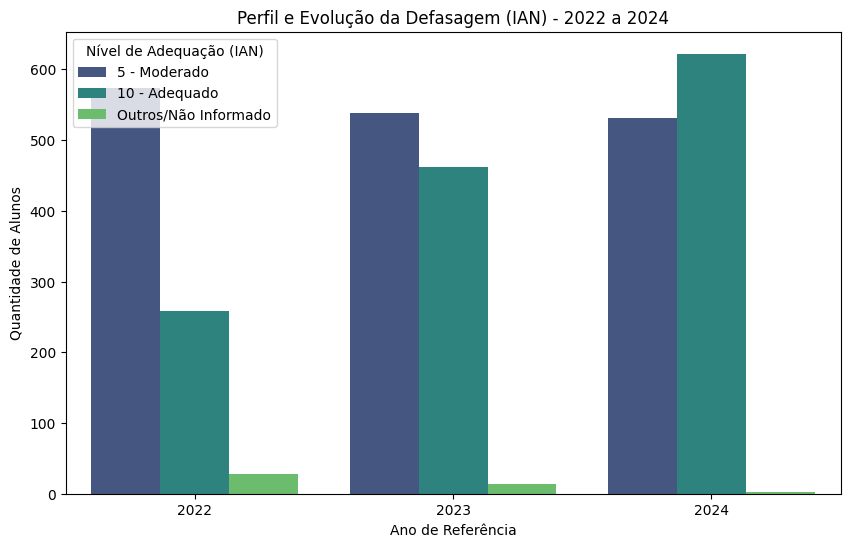

In [41]:
df_plot = base.copy()
df_plot['IAN_cat'] = df_plot['IAN'].astype(float).map({
    0.0: '0 - Severo',
    5.0: '5 - Moderado',
    10.0: '10 - Adequado'
}).fillna('Outros/Não Informado')

plt.figure(figsize=(10, 6))
sns.countplot(data=df_plot, x='ano_ref', hue='IAN_cat', palette='viridis')

plt.title('Perfil e Evolução da Defasagem (IAN) - 2022 a 2024')
plt.xlabel('Ano de Referência')
plt.ylabel('Quantidade de Alunos')
plt.legend(title='Nível de Adequação (IAN)')
plt.show()

,ano_ref,Fase_num,Fase_lbl,IAN
0,2022,0.0,F0,6.802632
1,2022,1.0,F1,5.742188
2,2022,2.0,F2,6.403226
3,2022,3.0,F3,6.993243
4,2022,4.0,F4,6.480263


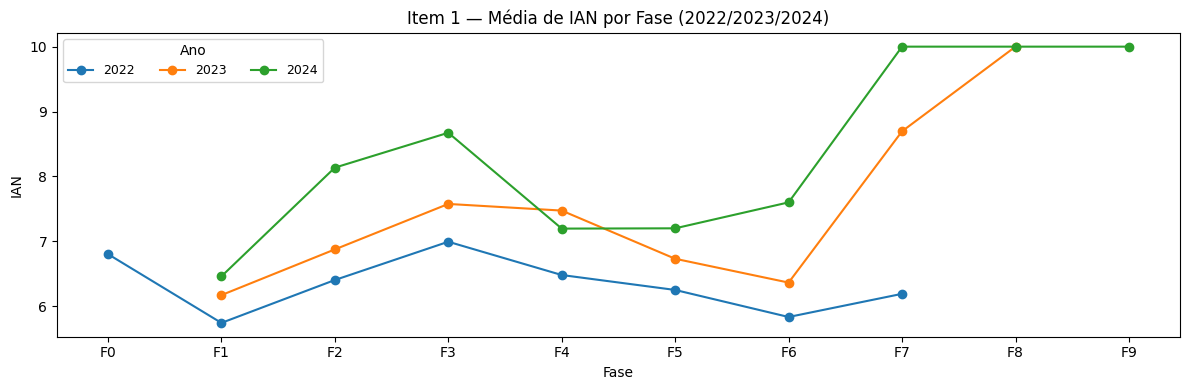

In [42]:
# ano como número (pra legenda ficar limpa)
tmp['ano_ref'] = pd.to_numeric(tmp.get('ano_ref'), errors='coerce')

# fase curta e ordenada: F1, F2, ...
fase_raw = tmp['Fase'].astype(str).str.strip()
fase_num = pd.to_numeric(fase_raw.str.extract(r'(\d+)')[0], errors='coerce')

# fallback se não tiver número na fase
if fase_num.isna().all():
    uniq = pd.Series(fase_raw.unique())
    mapping = {v: i+1 for i, v in enumerate(uniq)}
    fase_num = fase_raw.map(mapping)

tmp['Fase_num'] = fase_num
tmp['Fase_lbl'] = 'F' + tmp['Fase_num'].astype('Int64').astype(str)

# métrica numérica
tmp[metric] = pd.to_numeric(tmp[metric], errors='coerce')

# agrupar e ordenar por fase
grp = (tmp.dropna(subset=['ano_ref', 'Fase_num', metric])
         .groupby(['ano_ref', 'Fase_num', 'Fase_lbl'])[metric]
         .mean()
         .reset_index()
         .sort_values(['ano_ref', 'Fase_num']))

display(grp.head())

# ordem do eixo X
fase_order = [f'F{i}' for i in sorted(grp['Fase_num'].astype(int).unique())]

plt.figure(figsize=(12, 4))
for yr, g in grp.groupby('ano_ref'):
    plt.plot(g['Fase_lbl'], g[metric], marker='o', label=str(int(yr)))

plt.title(f'Item {item_num} — Média de {metric} por Fase (2022/2023/2024)')
plt.xlabel('Fase')
plt.ylabel(metric)
plt.legend(title='Ano', ncol=3, fontsize=9)
plt.xticks(fase_order, rotation=0)
plt.tight_layout()
plt.show()

**IDA (desempenho)** gráfico **Média de IDA por Fase (por ano)**

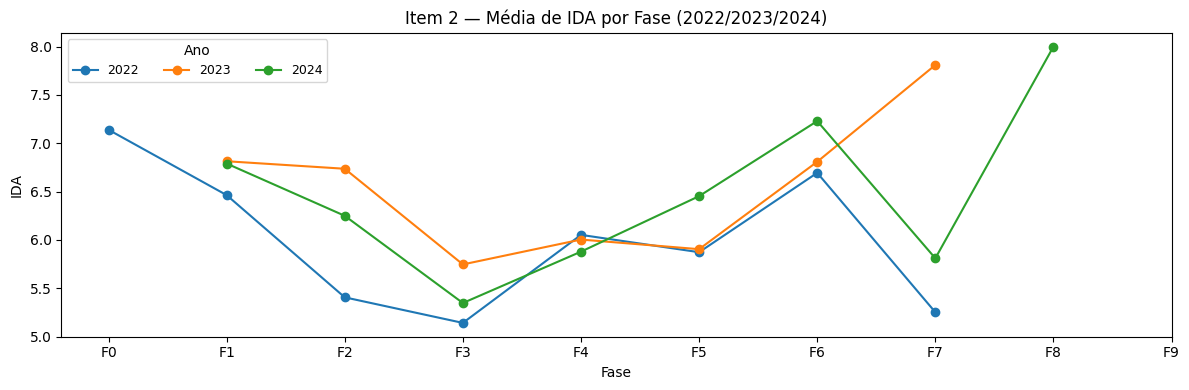

In [43]:

_plot_metric('IDA', 2, tmp, fase_order)

**IEG vs IDA e IPV** gráficos de **relação/correlação**: IEG×IDA e IEG×IPV. 

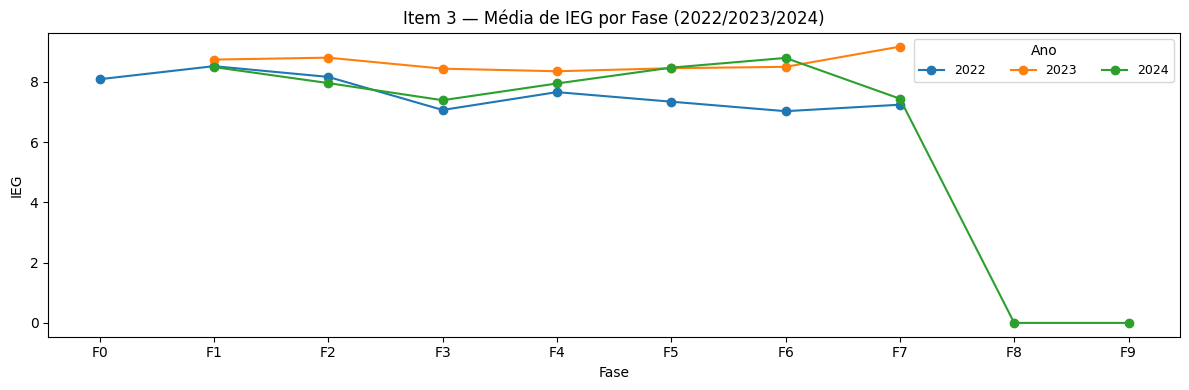

Corr IEG x IDA (Pearson): 0.539


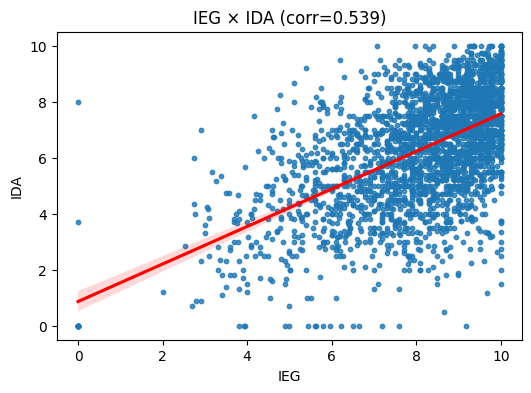

Corr IEG x IPV (Pearson): 0.558


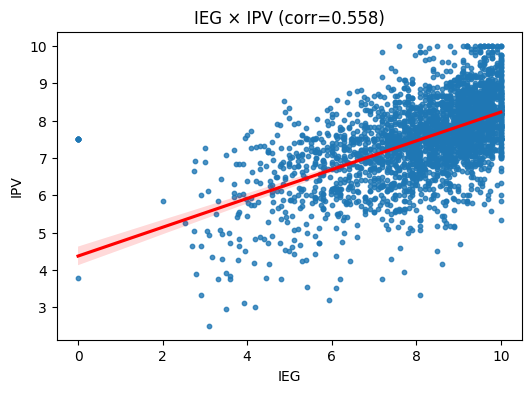

In [44]:
# IEG (e a relação com IDA/IPV fica nos scatters abaixo)
_plot_metric('IEG', 3, tmp, fase_order)

# IEG vs IDA and IEG vs IPV (scatter + Pearson)
if set(['IEG', 'IDA']).issubset(tmp.columns):
    s = tmp.dropna(subset=['IEG', 'IDA'])
    corr = s['IEG'].corr(s['IDA'])
    print('Corr IEG x IDA (Pearson):', round(corr, 3))
    plt.figure(figsize=(6, 4))
    sns.regplot(data=s, x='IEG', y='IDA', scatter_kws={
                's': 10}, line_kws={'color': 'red'})
    plt.title('IEG × IDA (corr='+str(round(corr, 3))+')')
    plt.show()

if set(['IEG', 'IPV']).issubset(tmp.columns):
    s = tmp.dropna(subset=['IEG', 'IPV'])
    corr = s['IEG'].corr(s['IPV'])
    print('Corr IEG x IPV (Pearson):', round(corr, 3))
    plt.figure(figsize=(6, 4))
    sns.regplot(data=s, x='IEG', y='IPV', scatter_kws={
                's': 10}, line_kws={'color': 'red'})
    plt.title('IEG × IPV (corr='+str(round(corr, 3))+')')
    plt.show()

**IAA coerente com IDA/IEG** gráficos de relação: IAA×IDA e IAA×IEG. 

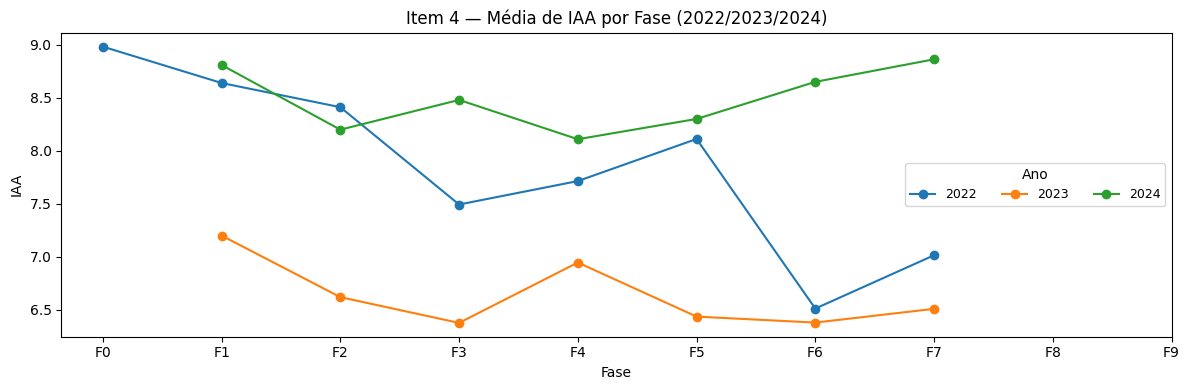

Corr IAA x IDA: 0.115


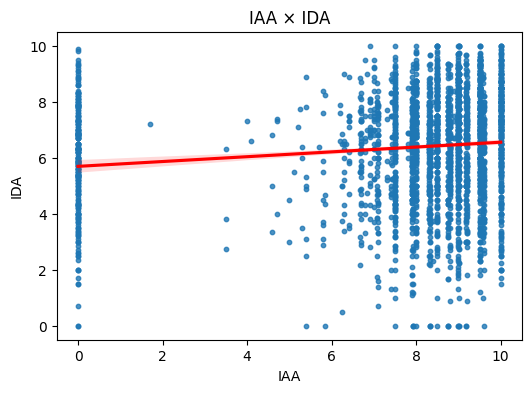

Corr IAA x IEG: 0.133


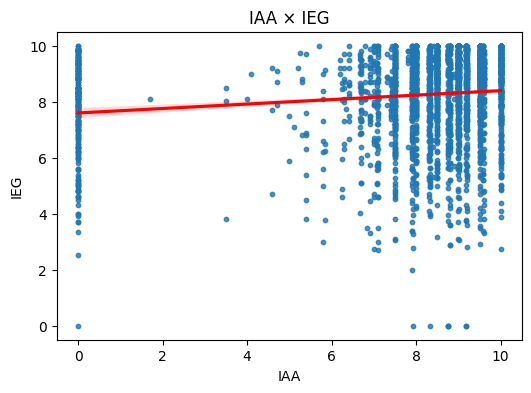

In [45]:
_plot_metric('IAA', 4, tmp, fase_order)

# IAA x IDA and IAA x IEG
if set(['IAA', 'IDA']).issubset(tmp.columns):
    s = tmp.dropna(subset=['IAA', 'IDA'])
    print('Corr IAA x IDA:', round(s['IAA'].corr(s['IDA']), 3))
    plt.figure(figsize=(6, 4))
    sns.regplot(data=s, x='IAA', y='IDA', scatter_kws={
                's': 10}, line_kws={'color': 'red'})
    plt.title('IAA × IDA')
    plt.show()

if set(['IAA', 'IEG']).issubset(tmp.columns):
    s = tmp.dropna(subset=['IAA', 'IEG'])
    print('Corr IAA x IEG:', round(s['IAA'].corr(s['IEG']), 3))
    plt.figure(figsize=(6, 4))
    sns.regplot(data=s, x='IAA', y='IEG', scatter_kws={
                's': 10}, line_kws={'color': 'red'})
    plt.title('IAA × IEG')
    plt.show()

**IPS antecede quedas** comparar IDA/IEG por faixas de IPS (ex.: boxplot por quartis).

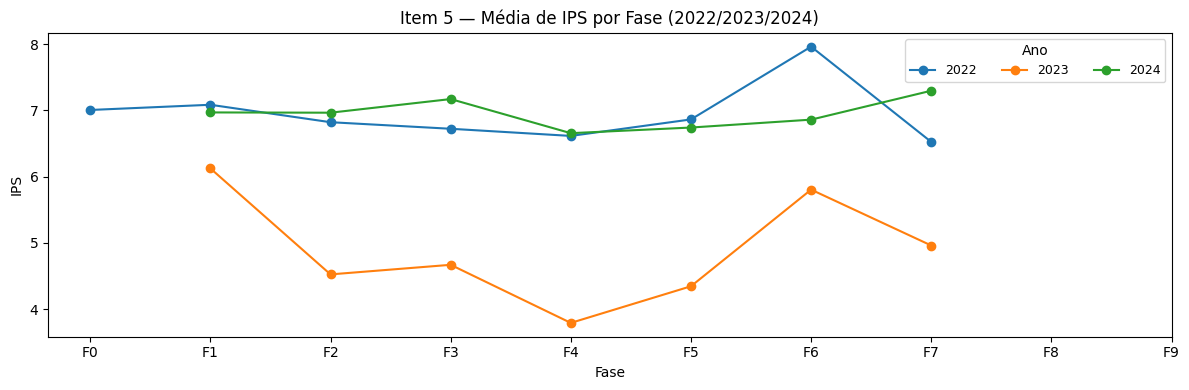

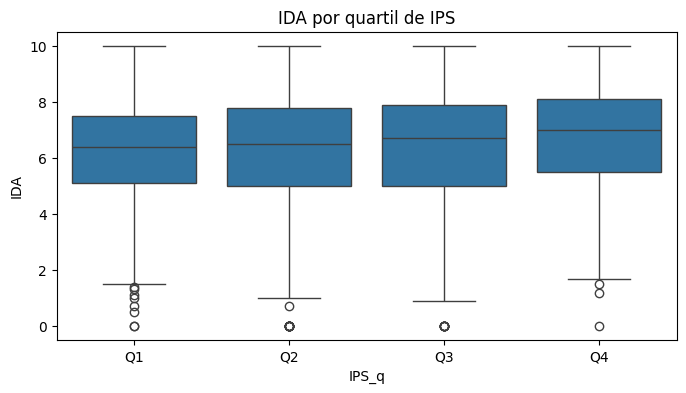

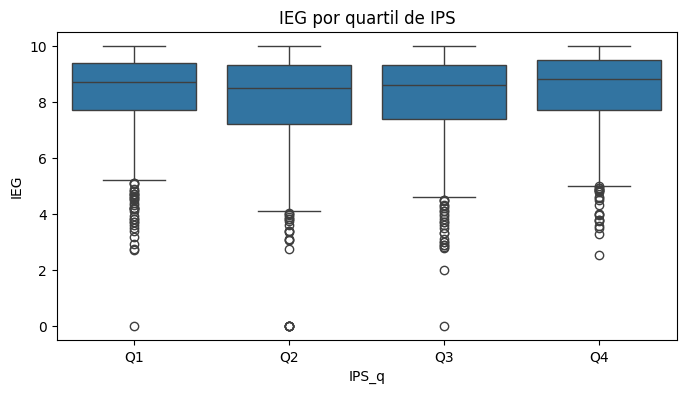

In [46]:
_plot_metric('IPS', 5, tmp, fase_order)

# IPS antecede quedas — boxplot por quartil de IPS para IDA e IEG
if 'IPS' in tmp.columns:
    tmp = tmp.copy()
    tmp['IPS_q'] = pd.qcut(tmp['IPS'].rank(method='first'),
                           4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    for metric in ['IDA', 'IEG']:
        if metric in tmp.columns:
            plt.figure(figsize=(8, 4))
            sns.boxplot(data=tmp, x='IPS_q', y=metric)
            plt.title(f'{metric} por quartil de IPS')
            plt.show()

**IPP confirma/contradiz IAN** comparar IPP por categorias de IAN (ex.: boxplot IPP por IAN_cat).  

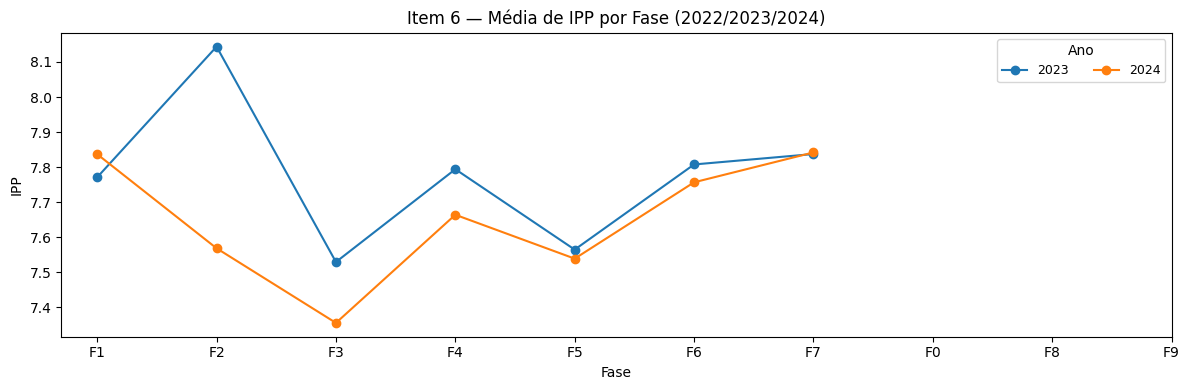

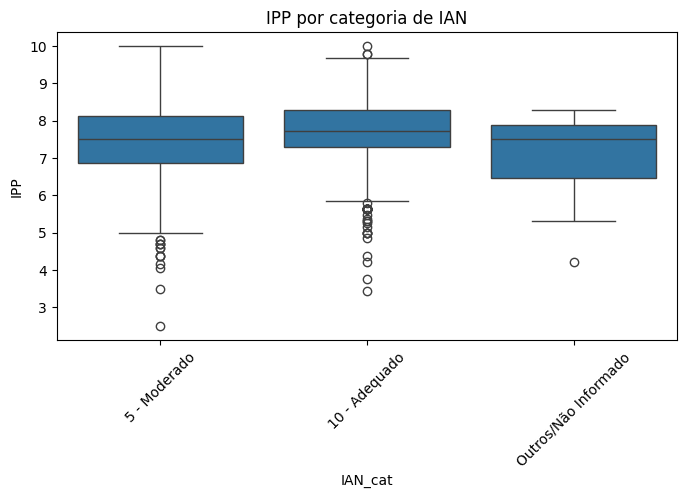

In [47]:
_plot_metric('IPP', 6, tmp, fase_order)

# IPP por categoria de IAN (boxplot)
if set(['IPP', 'IAN_cat']).issubset(tmp.columns):
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=tmp, x='IAN_cat', y='IPP')
    plt.title('IPP por categoria de IAN')
    plt.xticks(rotation=45)
    plt.show()

**O que influencia IPV** relação de IPV com variáveis (correlação/feature importance).  

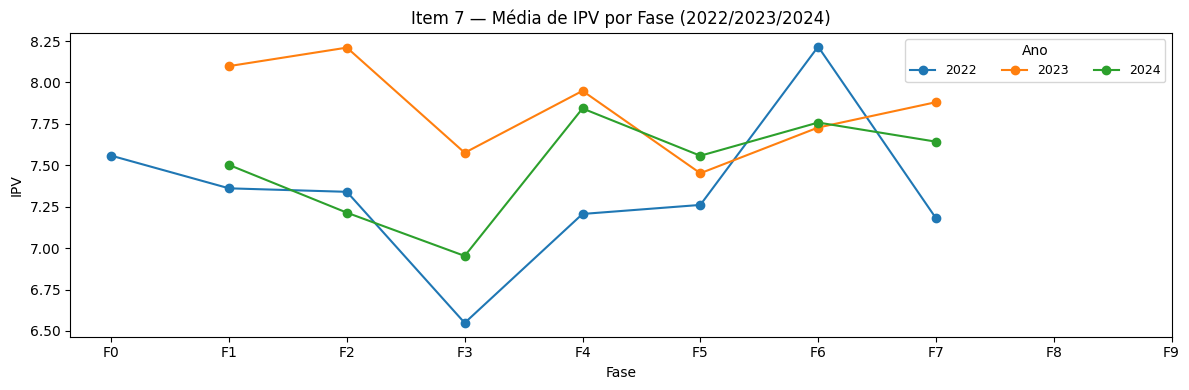

In [48]:
_plot_metric('IPV', 7, tmp, fase_order)

**Combinações explicam INDE** correlação (heatmap) e/ou modelo simples explicando INDE com IDA+IEG+IPS+IPP. 

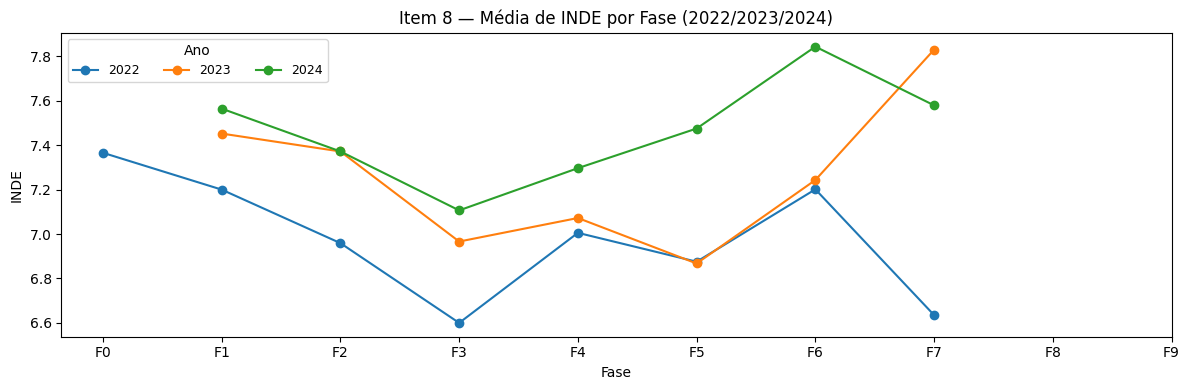

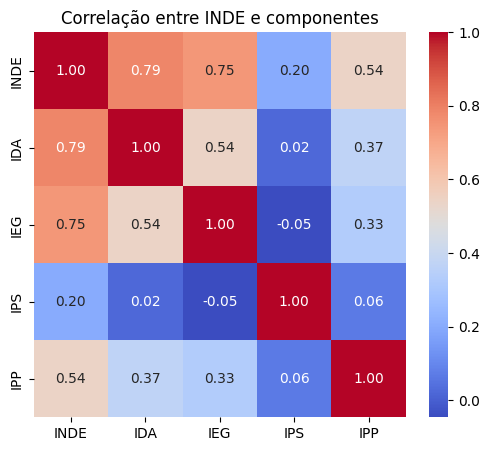

Regressão linear para INDE ~ ['IDA', 'IEG', 'IPS', 'IPP']
R^2: 0.823
Coeficientes: IDA    0.237186
IEG    0.254913
IPS    0.117792
IPP    0.226654
dtype: float64


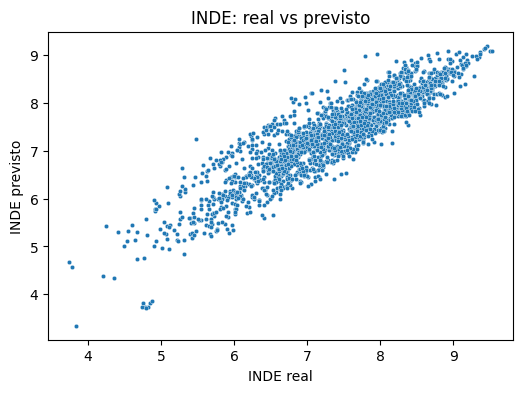

In [49]:
_plot_metric('INDE', 8, tmp, fase_order)

# Heatmap de correlação entre INDE e componentes (IDA, IEG, IPS, IPP)
cols = [c for c in ['INDE', 'IDA', 'IEG', 'IPS', 'IPP'] if c in tmp.columns]
if len(cols) > 1:
    corr = tmp[cols].corr()
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlação entre INDE e componentes')
    plt.show()

# Regressão simples explicando INDE com IDA+IEG+IPS+IPP
req = [c for c in ['IDA', 'IEG', 'IPS', 'IPP', 'INDE'] if c in tmp.columns]
if set(['INDE', 'IDA', 'IEG', 'IPS', 'IPP']).intersection(tmp.columns) and 'INDE' in tmp.columns:
    use = [c for c in ['IDA', 'IEG', 'IPS', 'IPP'] if c in tmp.columns]
    df_reg = tmp.dropna(subset=use+['INDE'])
    if len(df_reg) >= 10 and len(use) > 0:
        Xr = df_reg[use].values
        yr = df_reg['INDE'].values
        lr = LinearRegression()
        lr.fit(Xr, yr)
        pred = lr.predict(Xr)
        print('Regressão linear para INDE ~', use)
        print('R^2:', round(r2_score(yr, pred), 3))
        coefs = pd.Series(lr.coef_, index=use)
        print('Coeficientes:', coefs)
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=yr, y=pred, s=10)
        plt.xlabel('INDE real')
        plt.ylabel('INDE previsto')
        plt.title('INDE: real vs previsto')
        plt.show()
    else:
        print('Dados insuficientes para regressão INDE ou variáveis faltando.')